In [1]:
# initializing Spark session
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Heart Attack Analysis") \
    .getOrCreate()

In [2]:
pwd()

'C:\\Users\\Hi\\OneDrive - University of Oulu and Oamk\\Documents\\EBDS\\Big Data\\Project'

In [3]:
# # loading data
df = spark.read.csv(r"C:\Users\Hi\OneDrive - University of Oulu and Oamk\Documents\EBDS\Big Data\Project\dataset.csv", header = True, inferSchema = True)

In [4]:
df.printSchema()  #to check structure and data types

root
 |-- Country: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Cholesterol_Level: double (nullable = true)
 |-- Blood_Pressure: double (nullable = true)
 |-- Smoking_History: string (nullable = true)
 |-- Alcohol_Consumption: double (nullable = true)
 |-- Physical_Activity: string (nullable = true)
 |-- Obesity: string (nullable = true)
 |-- Diabetes: string (nullable = true)
 |-- Family_History: string (nullable = true)
 |-- Stress_Levels: double (nullable = true)
 |-- Dietary_Habits: string (nullable = true)
 |-- Heart_Attack_History: string (nullable = true)
 |-- Chest_Pain: string (nullable = true)
 |-- Exercise_Induced_Angina: string (nullable = true)
 |-- Resting_ECG: string (nullable = true)
 |-- Max_Heart_Rate_Achieved: integer (nullable = true)
 |-- Thalassemia: string (nullable = true)
 |-- HDL_Cholesterol: double (nullable = true)
 |-- LDL_Cholesterol: double (nullable = true)
 |-- Triglycerides: double (nullable = 

In [5]:
# Get dimensions
num_rows = df.count()
num_cols = len(df.columns)

print(f"Dataset dimensions: {num_rows} rows x {num_cols} columns")

# # Optional: Show column names to confirm what we’re working with
# print("Column names:", df.columns)

# # Optional: Peek at the first few rows
# df.show(5, truncate=False)

Dataset dimensions: 623027 rows x 30 columns


In [6]:
# checking for missing values for all columns
from pyspark.sql.functions import col, sum as _sum

missing_df = df.select([_sum(col(c).isNull().cast("int")).alias(c) for c in df.columns])

In [7]:
# Convert Spark DataFrame to Pandas for easy table format
missing_pd = missing_df.toPandas().T.reset_index()
missing_pd.columns = ['Column', 'MissingCount']
missing_pd = missing_pd.sort_values(by='MissingCount', ascending=False)

In [8]:
numerical_cols = [
    "Age", "Cholesterol_Level", "Blood_Pressure", "Alcohol_Consumption", "Stress_Levels",
    "Max_Heart_Rate_Achieved", "HDL_Cholesterol", "LDL_Cholesterol", "Triglycerides",
    "Air_Pollution_Exposure"
]

In [9]:
categorical_cols = [
     "Gender", "Smoking_History", "Physical_Activity", "Obesity", "Diabetes",
    "Family_History", "Dietary_Habits", "Heart_Attack_History", "Chest_Pain",
    "Exercise_Induced_Angina", "Resting_ECG", "Thalassemia", "Heart_Disease_Risk",
    "Medication_Adherence", "Urbanization_Level", "Access_To_Healthcare",
    "Education_Level", "Income_Level", "Country"
]

In [10]:
# View missing values separately for categorical and numerical columns
missing_cat = missing_pd[missing_pd['Column'].isin(categorical_cols)]
missing_num = missing_pd[missing_pd['Column'].isin(numerical_cols)]

In [11]:
print("Missing values in categorical variables:")
display(missing_cat)

print("\nMissing values in numerical variables:")
display(missing_num)

Missing values in categorical variables:


,Column,MissingCount
0,Country,0
28,Income_Level,0
27,Education_Level,0
26,Access_To_Healthcare,0
24,Urbanization_Level,0
23,Medication_Adherence,0
22,Heart_Disease_Risk,0
18,Thalassemia,0
16,Resting_ECG,0
15,Exercise_Induced_Angina,0



Missing values in numerical variables:


,Column,MissingCount
1,Age,0
25,Air_Pollution_Exposure,0
21,Triglycerides,0
20,LDL_Cholesterol,0
19,HDL_Cholesterol,0
17,Max_Heart_Rate_Achieved,0
11,Stress_Levels,0
6,Alcohol_Consumption,0
4,Blood_Pressure,0
3,Cholesterol_Level,0


In [14]:
import sys
print(sys.executable)

C:\Users\Hi\anaconda3\envs\pyspark_env\python.exe


In [16]:
!where pip

C:\Users\Hi\miniconda3\Scripts\pip.exe
C:\Users\Hi\anaconda3\Scripts\pip.exe


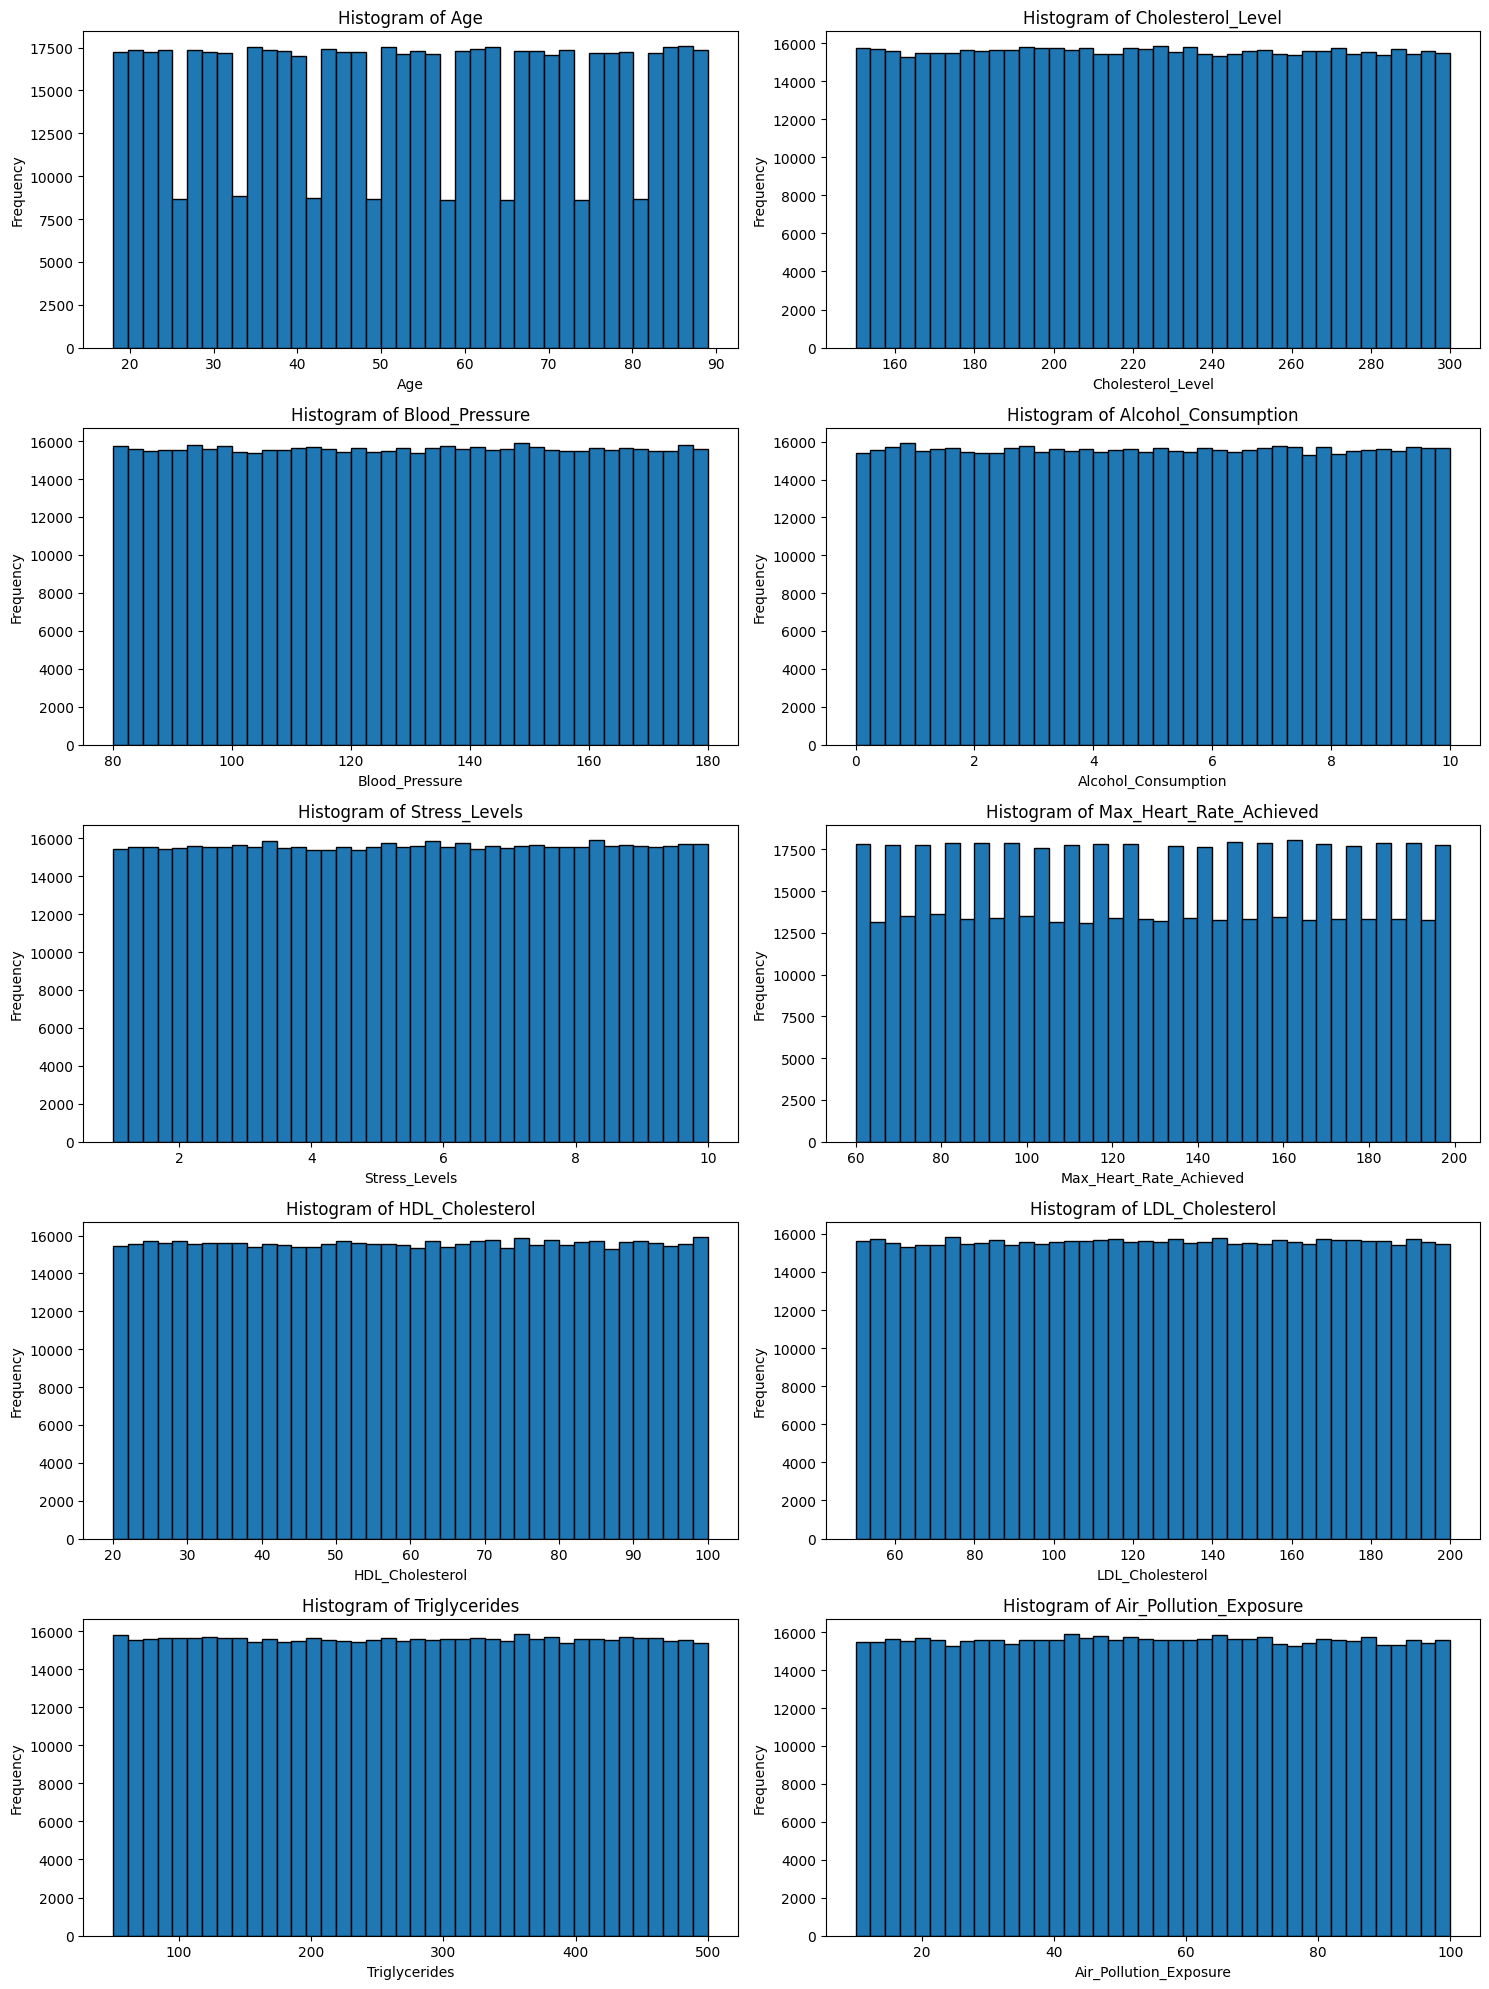

In [17]:
import pandas as pd
!pip install matplotlib
import matplotlib.pyplot as plt

# Convert Spark DataFrame to Pandas DataFrame
df_pandas = df.toPandas()

# Create subplots for histograms
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df_pandas[col], bins=40, edgecolor='black')
    axes[i].set_title(f"Histogram of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


In [13]:
from pyspark.sql import SparkSession

# Select numerical columns
numerical_df = df.select(numerical_cols)

# Show summary statistics for numerical columns
summary = numerical_df.describe()

# Convert Spark DataFrame to Pandas DataFrame for easy visualization
summary_pd = summary.toPandas()

# Display the summary statistics in a data table format
from IPython.display import display
display(summary_pd)

,summary,Age,Cholesterol_Level,Blood_Pressure,Alcohol_Consumption,Stress_Levels,Max_Heart_Rate_Achieved,HDL_Cholesterol,LDL_Cholesterol,Triglycerides,Air_Pollution_Exposure
0,count,623027,623027,623027,623027,623027,623027,623027,623027,623027,623027
1,mean,53.50602943371636,224.92318155523745,130.0087232477701,5.0004825706257385,5.5069050840176965,129.48706235845316,60.031667949812295,125.0436377455666,274.8579775722941,54.97498666239438
2,stddev,20.79161450183394,43.27261880518774,28.875587773884682,2.888440616599642,2.5984303743857,40.42406856051616,23.112244830013992,43.28082571232524,129.92503306040837,25.94240977732405
3,min,18,150.0000566186415,80.00009958058023,1.3656572108722287E-5,1.0000142421860696,60,20.000070711822595,50.00005748425069,50.00109622685509,10.000151073508462
4,max,89,299.9999073362229,179.99978869129643,9.999989756148102,9.999970111196948,199,99.9999818571535,199.99992371635474,499.9992089638228,99.99988143747274


In [93]:
from pyspark.sql import DataFrame
from pyspark.sql.functions import col, count, round, lit
from typing import List
from functools import reduce

def summarize_categorical(df: DataFrame, categorical_cols: List[str]) -> DataFrame:
  
    summary_data = []
    total_rows = df.count()  # Calculate total rows once

    for col_name in categorical_cols:
        counts_with_percentage = (
            df.groupBy(col_name)
            .agg(count("*").alias("Count"))
            .withColumn("Percentage", round(col("Count") / total_rows * 100, 2))
            .withColumn("Category", lit(col_name))
            .select(col("Category"), col(col_name).alias("Value"), col("Count"), col("Percentage"))
        )
        summary_data.append(counts_with_percentage)

    if summary_data:
        return reduce(DataFrame.unionAll, summary_data)
    else:
        return spark.createDataFrame([], ["Category", "Value", "Count", "Percentage"])

# Example usage:
# Assuming you have a Spark DataFrame called 'df' and a list of categorical columns called 'categorical_cols'
summary_df = summarize_categorical(df, categorical_cols)
summary_df.show(truncate=False)

+--------------------+---------+------+----------+
|Category            |Value    |Count |Percentage|
+--------------------+---------+------+----------+
|Gender              |Female   |311574|50.01     |
|Gender              |Male     |311453|49.99     |
|Smoking_History     |Former   |208249|33.43     |
|Smoking_History     |Never    |207462|33.3      |
|Smoking_History     |Current  |207316|33.28     |
|Physical_Activity   |Active   |207843|33.36     |
|Physical_Activity   |Moderate |207489|33.3      |
|Physical_Activity   |Sedentary|207695|33.34     |
|Obesity             |No       |311696|50.03     |
|Obesity             |Yes      |311331|49.97     |
|Diabetes            |No       |311400|49.98     |
|Diabetes            |Yes      |311627|50.02     |
|Family_History      |No       |311812|50.05     |
|Family_History      |Yes      |311215|49.95     |
|Dietary_Habits      |Unhealthy|207775|33.35     |
|Dietary_Habits      |Healthy  |207896|33.37     |
|Dietary_Habits      |Moderate 

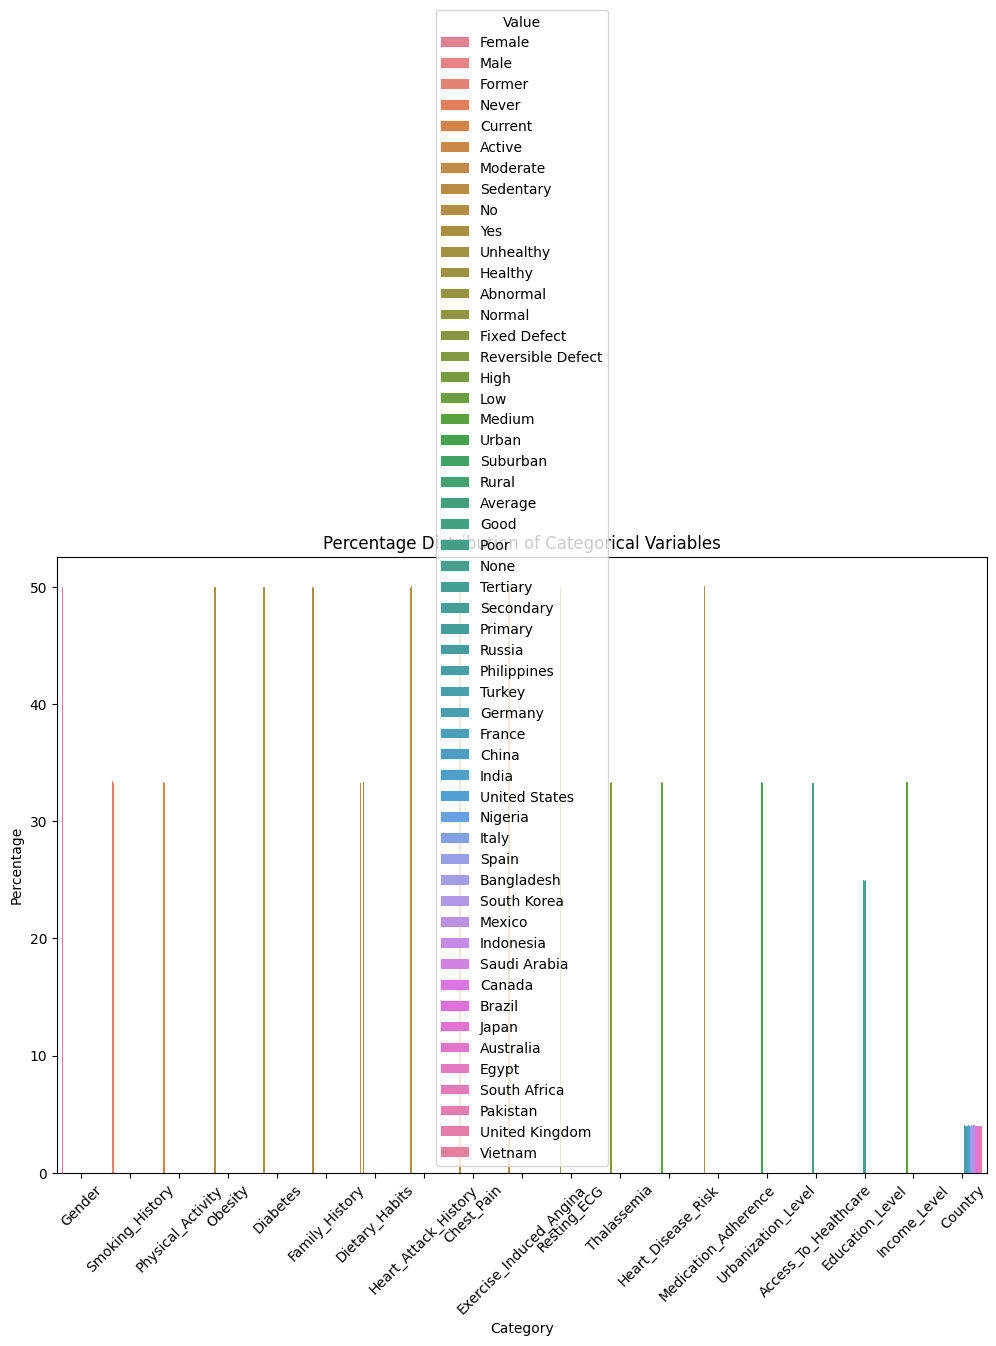

In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the summary DataFrame to Pandas
summary_pd_df = summary_df.toPandas()

# Create a bar plot for better visualization
plt.figure(figsize=(12, 8))
sns.barplot(data=summary_pd_df, x='Category', y='Percentage', hue='Value')
plt.title('Percentage Distribution of Categorical Variables')
plt.xlabel('Category')
plt.ylabel('Percentage')
plt.legend(title='Value')
plt.xticks(rotation=45)
plt.show()

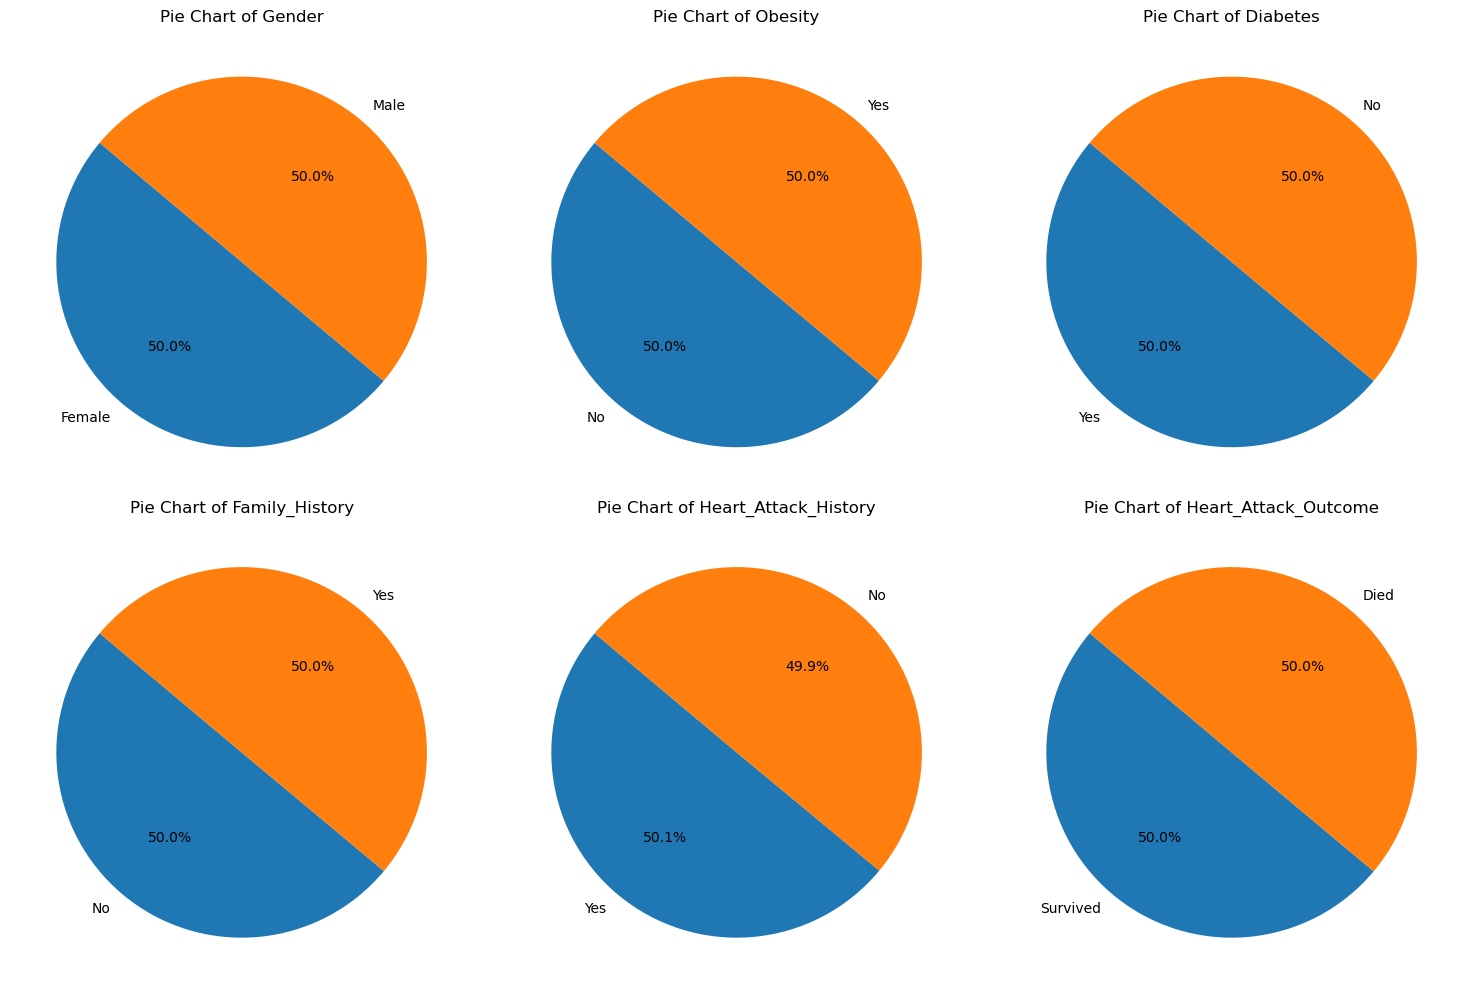

In [15]:
from pyspark.sql import SparkSession
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'df' is a Spark DataFrame
# Define the categorical columns for the pie charts
categorical_cols_pie = [
    "Gender", "Obesity", "Diabetes", "Family_History", 
    "Heart_Attack_History", "Heart_Attack_Outcome"
]

# Convert Spark DataFrame to Pandas DataFrame (consider aggregating first if large)
df_pandas = df.select(categorical_cols_pie).toPandas()

# Validate columns
for col in categorical_cols_pie:
    if col not in df_pandas.columns:
        print(f"Column {col} not found in DataFrame")
        categorical_cols_pie.remove(col)

# Create dynamic subplot grid
n_cols = 3
n_rows = (len(categorical_cols_pie) + n_cols - 1) // n_cols
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(n_cols * 5, n_rows * 5))
axes = axes.flatten()

# Generate pie charts
for i, col in enumerate(categorical_cols_pie):
    # Handle missing values
    counts = df_pandas[col].fillna("Missing").value_counts()
    # Limit categories for readability
    max_categories = 10
    if len(counts) > max_categories:
        others = counts[max_categories-1:].sum()
        counts = counts[:max_categories-1]
        counts["Other"] = others
    axes[i].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140)
    axes[i].set_title(f"Pie Chart of {col}")

# Hide unused subplots
for i in range(len(categorical_cols_pie), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.savefig("pie_charts.png")  # Save to file for compatibility
plt.show()

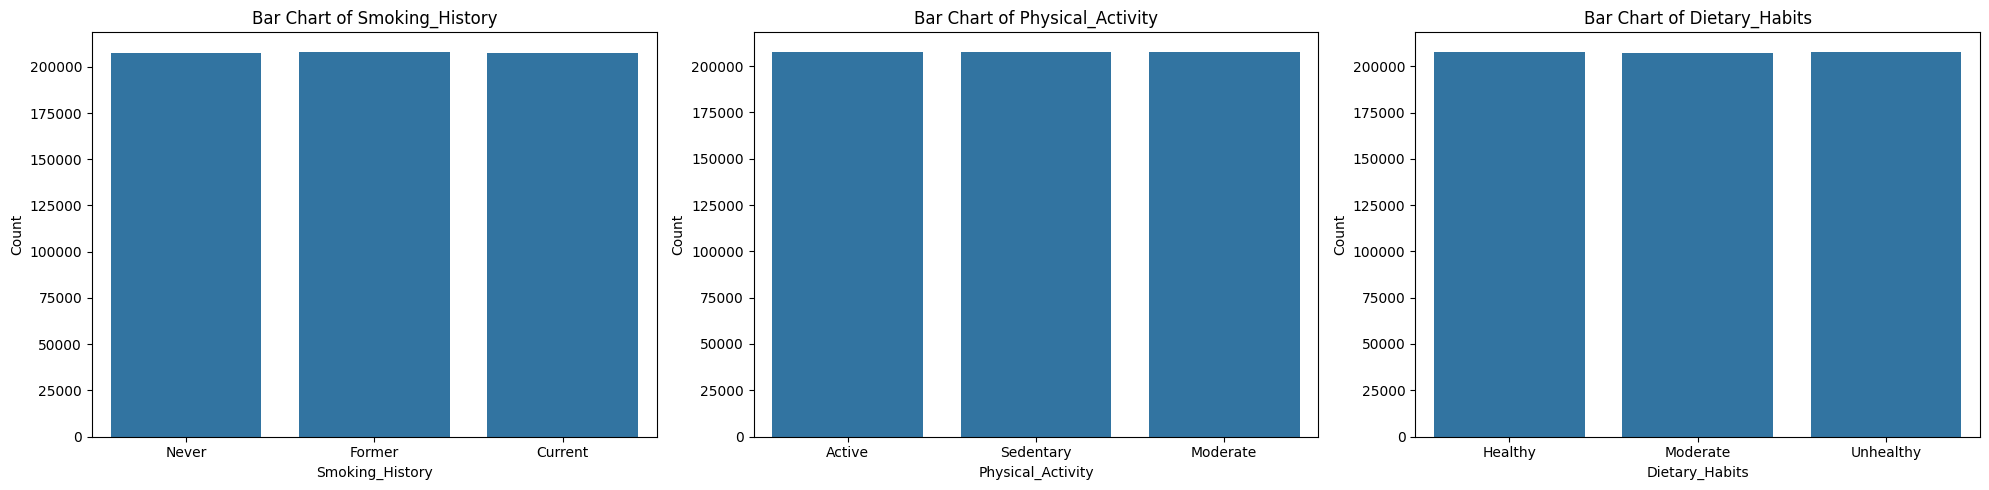

In [20]:
from pyspark.sql import SparkSession
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the categorical columns for the bar charts
categorical_cols_bar = [
    "Smoking_History", "Physical_Activity", "Dietary_Habits"
]

# Convert Spark DataFrame to Pandas DataFrame
df_pandas = df.toPandas()

# Create subplots for bar charts
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 5))
axes = axes.flatten()

for i, col in enumerate(categorical_cols_bar):
    sns.countplot(x=col, data=df_pandas, ax=axes[i])
    axes[i].set_title(f"Bar Chart of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()


In [21]:
# Number of distinct values for each categorical variable

for col in categorical_cols:
    count = df.select(col).distinct().count()
    print(f"{col}: {count} distinct values")

Gender: 2 distinct values
Smoking_History: 3 distinct values
Physical_Activity: 3 distinct values
Obesity: 2 distinct values
Diabetes: 2 distinct values
Family_History: 2 distinct values
Dietary_Habits: 3 distinct values
Heart_Attack_History: 2 distinct values
Chest_Pain: 2 distinct values
Exercise_Induced_Angina: 2 distinct values
Resting_ECG: 2 distinct values
Thalassemia: 3 distinct values
Heart_Disease_Risk: 3 distinct values
Medication_Adherence: 2 distinct values
Urbanization_Level: 3 distinct values
Access_To_Healthcare: 3 distinct values
Education_Level: 4 distinct values
Income_Level: 3 distinct values
Country: 25 distinct values


In [22]:
# considerated numerical variables for further analysis based on literature
num_col = [
    "Blood_Pressure", 
    "HDL_Cholesterol", "LDL_Cholesterol", "Triglycerides",
]


In [23]:
# considerated categorical variables for further analysis based on literature
cat_col = [
    "Gender", "Smoking_History", "Physical_Activity", "Obesity", "Diabetes",
    "Family_History", "Dietary_Habits", "Heart_Attack_History", "Heart_Attack_Outcome"
]

In [24]:
import pandas as pd

# Select the specified variables
selected_columns = [
    "Age", "Blood_Pressure", "HDL_Cholesterol", "LDL_Cholesterol", "Triglycerides",
    "Gender", "Smoking_History", "Physical_Activity", "Obesity", "Diabetes",
    "Family_History", "Dietary_Habits", "Heart_Attack_History", "Heart_Attack_Outcome"
]

# Create a new dataset with the selected variables
new_df = df[selected_columns]

In [25]:
# Calculate quartiles for the Age column
age_quartiles = new_df.approxQuantile("Age", [0.25, 0.5, 0.75], 0.01)

# Print the quartiles
print(f"25th percentile (Q1): {age_quartiles[0]}")
print(f"50th percentile (Q2/Median): {age_quartiles[1]}")
print(f"75th percentile (Q3): {age_quartiles[2]}")

25th percentile (Q1): 36.0
50th percentile (Q2/Median): 53.0
75th percentile (Q3): 71.0


In [26]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import when, col

# Define quartile boundaries for age
age_quartiles = [18, 35, 53, 71, 89]

# Create a new column for age quartiles
new_df = new_df.withColumn(
    "Age_Quartile",
    when(col("Age") <= age_quartiles[1], "18-34")
    .when((col("Age") > age_quartiles[1]) & (col("Age") <= age_quartiles[2]), "35-53")
    .when((col("Age") > age_quartiles[2]) & (col("Age") <= age_quartiles[3]), "54-71")
    .otherwise("72-89")
)

# Show the new dataframe with age quartiles
new_df.show(5, truncate=False)

+---+------------------+-----------------+------------------+------------------+------+---------------+-----------------+-------+--------+--------------+--------------+--------------------+--------------------+------------+
|Age|Blood_Pressure    |HDL_Cholesterol  |LDL_Cholesterol   |Triglycerides     |Gender|Smoking_History|Physical_Activity|Obesity|Diabetes|Family_History|Dietary_Habits|Heart_Attack_History|Heart_Attack_Outcome|Age_Quartile|
+---+------------------+-----------------+------------------+------------------+------+---------------+-----------------+-------+--------+--------------+--------------+--------------------+--------------------+------------+
|39 |173.30164988119017|96.54552203173441|68.33357254046015 |165.06089695495723|Male  |Never          |Active           |No     |No      |Yes           |Healthy       |Yes                 |Died                |35-53       |
|88 |137.38167772509746|92.52464360008666|98.19401509632416 |452.12465112405266|Male  |Former         |S

In [27]:
import pandas as pd

# Select the specified variables
selected_col1 = [
    "Age_Quartile","Blood_Pressure", "HDL_Cholesterol", "LDL_Cholesterol", "Triglycerides",
    "Gender", "Smoking_History", "Physical_Activity", "Obesity", "Diabetes",
    "Family_History", "Dietary_Habits", "Heart_Attack_History", "Heart_Attack_Outcome"
]

# Create a new dataset with the selected variables
new_df_1 = new_df[selected_col1]

In [28]:
new_df_1.show(5, truncate=False)

+------------+------------------+-----------------+------------------+------------------+------+---------------+-----------------+-------+--------+--------------+--------------+--------------------+--------------------+
|Age_Quartile|Blood_Pressure    |HDL_Cholesterol  |LDL_Cholesterol   |Triglycerides     |Gender|Smoking_History|Physical_Activity|Obesity|Diabetes|Family_History|Dietary_Habits|Heart_Attack_History|Heart_Attack_Outcome|
+------------+------------------+-----------------+------------------+------------------+------+---------------+-----------------+-------+--------+--------------+--------------+--------------------+--------------------+
|35-53       |173.30164988119017|96.54552203173441|68.33357254046015 |165.06089695495723|Male  |Never          |Active           |No     |No      |Yes           |Healthy       |Yes                 |Died                |
|72-89       |137.38167772509746|92.52464360008666|98.19401509632416 |452.12465112405266|Male  |Former         |Sedentar

In [29]:
# Get dimensions for the new dataset
num_rows = new_df_1.count()
num_cols = len(new_df_1.columns)

print(f"Dataset dimensions: {num_rows} rows x {num_cols} columns")

# # Optional: Show column names to confirm what we’re working with
# print("Column names:", new_df_1.columns)

# # Optional: Peek at the first few rows
# new_df_1.show(5, truncate=False)

Dataset dimensions: 623027 rows x 14 columns


In [30]:
## standardizing the numerical variables

from pyspark.sql import SparkSession
from pyspark.ml.feature import StandardScaler, VectorAssembler

# Assemble numerical columns into a single vector column
assembler = VectorAssembler(inputCols=num_col, outputCol="features")
assembled_df = assembler.transform(new_df_1)

# Standardize the numerical columns
scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withMean=True, withStd=True)
scaler_model = scaler.fit(assembled_df)
scaled_df = scaler_model.transform(assembled_df)

# Show the standardized numerical columns
scaled_df.select("scaled_features").show(5, truncate=False)


+----------------------------------------------------------------------------------+
|scaled_features                                                                   |
+----------------------------------------------------------------------------------+
|[1.499291615202175,1.5798488788291354,-1.3102814992958154,-0.8450802592159933]    |
|[0.2553352172451772,1.4058770962861364,-0.6203583736526614,1.364376589916581]     |
|[0.33692662136271234,0.49800308009535976,-0.14500557897062338,-0.7960387255547108]|
|[-1.5243296989736144,-0.7805740388392362,1.5052152606241969,0.4209756894783032]   |
|[-0.35067223081806054,0.9890229761031543,1.459439223794738,1.3476625109188851]    |
+----------------------------------------------------------------------------------+
only showing top 5 rows



In [31]:
new_df_1.dtypes

[('Age_Quartile', 'string'),
 ('Blood_Pressure', 'double'),
 ('HDL_Cholesterol', 'double'),
 ('LDL_Cholesterol', 'double'),
 ('Triglycerides', 'double'),
 ('Gender', 'string'),
 ('Smoking_History', 'string'),
 ('Physical_Activity', 'string'),
 ('Obesity', 'string'),
 ('Diabetes', 'string'),
 ('Family_History', 'string'),
 ('Dietary_Habits', 'string'),
 ('Heart_Attack_History', 'string'),
 ('Heart_Attack_Outcome', 'string')]

In [32]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.sql.functions import col

# Define numerical columns
num_cols = ['Blood_Pressure', 'HDL_Cholesterol', 'LDL_Cholesterol', 'Triglycerides']

# Assemble numerical columns into a single vector column
assembler = VectorAssembler(inputCols=num_cols, outputCol="features")
assembled_df = assembler.transform(new_df_1)

# Convert the assembled vector column to a DataFrame with individual columns
assembled_df = assembled_df.select([col(c) for c in num_cols])

# Calculate the correlation matrix
correlation_matrix = assembled_df.toPandas().corr()

# Display the correlation matrix
print(correlation_matrix)


                 Blood_Pressure  HDL_Cholesterol  LDL_Cholesterol  \
Blood_Pressure         1.000000         0.001322        -0.000139   
HDL_Cholesterol        0.001322         1.000000        -0.002659   
LDL_Cholesterol       -0.000139        -0.002659         1.000000   
Triglycerides         -0.000430         0.001169         0.001759   

                 Triglycerides  
Blood_Pressure       -0.000430  
HDL_Cholesterol       0.001169  
LDL_Cholesterol       0.001759  
Triglycerides         1.000000  


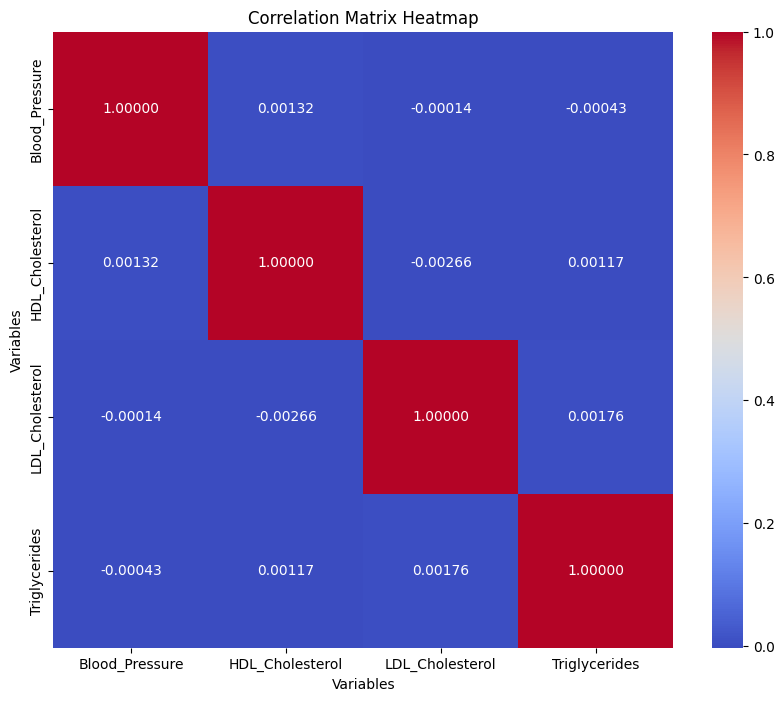

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.5f')

# Add title and labels
plt.title('Correlation Matrix Heatmap')
plt.xlabel('Variables')
plt.ylabel('Variables')

# Display the heatmap
plt.show()

In [34]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when

# Define quartile boundaries for age
age_quartiles = [18, 35, 53, 71, 89]

# Create a new column for age quartiles with descriptive labels
new_df = new_df.withColumn(
    "Age_Quartile",
    when(col("Age") <= age_quartiles[1], "young")
    .when((col("Age") > age_quartiles[1]) & (col("Age") <= age_quartiles[2]), "middle_age")
    .when((col("Age") > age_quartiles[2]) & (col("Age") <= age_quartiles[3]), "senior")
    .otherwise("elderly")
)

# Show the new dataframe with age quartiles
new_df.show(5, truncate=False)


+---+------------------+-----------------+------------------+------------------+------+---------------+-----------------+-------+--------+--------------+--------------+--------------------+--------------------+------------+
|Age|Blood_Pressure    |HDL_Cholesterol  |LDL_Cholesterol   |Triglycerides     |Gender|Smoking_History|Physical_Activity|Obesity|Diabetes|Family_History|Dietary_Habits|Heart_Attack_History|Heart_Attack_Outcome|Age_Quartile|
+---+------------------+-----------------+------------------+------------------+------+---------------+-----------------+-------+--------+--------------+--------------+--------------------+--------------------+------------+
|39 |173.30164988119017|96.54552203173441|68.33357254046015 |165.06089695495723|Male  |Never          |Active           |No     |No      |Yes           |Healthy       |Yes                 |Died                |middle_age  |
|88 |137.38167772509746|92.52464360008666|98.19401509632416 |452.12465112405266|Male  |Former         |S

In [35]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import when, col

# Change values for Age_Quartile variable
new_df_1 = new_df_1.withColumn(
    "Age_Quartile",
    when(col("Age_Quartile") == "young", 1)
    .when(col("Age_Quartile") == "middle_age", 2)
    .when(col("Age_Quartile") == "senior", 3)
    .otherwise(4)
)

# Show the new dataframe new_df1 with renamed values
new_df_1.show(5, truncate=False)


+------------+------------------+-----------------+------------------+------------------+------+---------------+-----------------+-------+--------+--------------+--------------+--------------------+--------------------+
|Age_Quartile|Blood_Pressure    |HDL_Cholesterol  |LDL_Cholesterol   |Triglycerides     |Gender|Smoking_History|Physical_Activity|Obesity|Diabetes|Family_History|Dietary_Habits|Heart_Attack_History|Heart_Attack_Outcome|
+------------+------------------+-----------------+------------------+------------------+------+---------------+-----------------+-------+--------+--------------+--------------+--------------------+--------------------+
|4           |173.30164988119017|96.54552203173441|68.33357254046015 |165.06089695495723|Male  |Never          |Active           |No     |No      |Yes           |Healthy       |Yes                 |Died                |
|4           |137.38167772509746|92.52464360008666|98.19401509632416 |452.12465112405266|Male  |Former         |Sedentar

In [36]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import when, col

# Rename values in additional specified columns
new_df_1 = new_df_1.withColumn("Gender", when(col("Gender") == "Female", 1).otherwise(2))
new_df_1 = new_df_1.withColumn("Smoking_History",
                             when(col("Smoking_History") == "Former", 2)
                             .when(col("Smoking_History") == "Never", 3)
                             .otherwise(1))
new_df_1 = new_df_1.withColumn("Physical_Activity",
                             when(col("Physical_Activity") == "Active", 1)
                             .when(col("Physical_Activity") == "Sedentary", 3)
                             .otherwise(2))
new_df_1 = new_df_1.withColumn("Dietary_Habits",
                             when(col("Dietary_Habits") == "Healthy", 1)
                             .when(col("Dietary_Habits") == "Unhealthy", 3)
                             .otherwise(2))
new_df_1 = new_df_1.withColumn("Heart_Attack_Outcome",
                             when(col("Heart_Attack_Outcome") == "Died", 1)
                             .otherwise(0))

# Show the new dataframe new_df_1 with renamed values
new_df_1.show(5, truncate=False)


+------------+------------------+-----------------+------------------+------------------+------+---------------+-----------------+-------+--------+--------------+--------------+--------------------+--------------------+
|Age_Quartile|Blood_Pressure    |HDL_Cholesterol  |LDL_Cholesterol   |Triglycerides     |Gender|Smoking_History|Physical_Activity|Obesity|Diabetes|Family_History|Dietary_Habits|Heart_Attack_History|Heart_Attack_Outcome|
+------------+------------------+-----------------+------------------+------------------+------+---------------+-----------------+-------+--------+--------------+--------------+--------------------+--------------------+
|4           |173.30164988119017|96.54552203173441|68.33357254046015 |165.06089695495723|2     |3              |1                |No     |No      |Yes           |1             |Yes                 |1                   |
|4           |137.38167772509746|92.52464360008666|98.19401509632416 |452.12465112405266|2     |2              |3       

In [37]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import when, col

# Rename values in specified columns
columns_to_rename = ["Diabetes", "Obesity", "Family_History", "Heart_Attack_History"]
for column in columns_to_rename:
    new_df_1 = new_df_1.withColumn(column, when(col(column) == "Yes", 1).otherwise(2))

# Show the new dataframe new_df1 with renamed values
new_df_1.show(5, truncate=False)


+------------+------------------+-----------------+------------------+------------------+------+---------------+-----------------+-------+--------+--------------+--------------+--------------------+--------------------+
|Age_Quartile|Blood_Pressure    |HDL_Cholesterol  |LDL_Cholesterol   |Triglycerides     |Gender|Smoking_History|Physical_Activity|Obesity|Diabetes|Family_History|Dietary_Habits|Heart_Attack_History|Heart_Attack_Outcome|
+------------+------------------+-----------------+------------------+------------------+------+---------------+-----------------+-------+--------+--------------+--------------+--------------------+--------------------+
|4           |173.30164988119017|96.54552203173441|68.33357254046015 |165.06089695495723|2     |3              |1                |2      |2       |1             |1             |1                   |1                   |
|4           |137.38167772509746|92.52464360008666|98.19401509632416 |452.12465112405266|2     |2              |3       

In [38]:
ordi_cat=['Smoking_History','Physical_Activity', 'Age_Quartile','Dietary_Habits']

In [39]:
print(ordi_cat)

['Smoking_History', 'Physical_Activity', 'Age_Quartile', 'Dietary_Habits']


In [40]:
new_df_1.dtypes

[('Age_Quartile', 'int'),
 ('Blood_Pressure', 'double'),
 ('HDL_Cholesterol', 'double'),
 ('LDL_Cholesterol', 'double'),
 ('Triglycerides', 'double'),
 ('Gender', 'int'),
 ('Smoking_History', 'int'),
 ('Physical_Activity', 'int'),
 ('Obesity', 'int'),
 ('Diabetes', 'int'),
 ('Family_History', 'int'),
 ('Dietary_Habits', 'int'),
 ('Heart_Attack_History', 'int'),
 ('Heart_Attack_Outcome', 'int')]

## Logistic Regression

In [41]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder
from pyspark.ml.classification import LogisticRegression
from pyspark.sql.functions import col, when

# Define numerical, ordinal, and nominal columns
num_cols = ['Blood_Pressure', 'HDL_Cholesterol', 'LDL_Cholesterol', 'Triglycerides']
ordinal_cols = ['Smoking_History', 'Physical_Activity', 'Age_Quartile', 'Dietary_Habits']
nominal_cols = ['Gender', 'Obesity', 'Diabetes', 'Family_History', 'Heart_Attack_History', "target"]


In [42]:
# Define the order for ordinal columns
ordinal_order = {
    'Smoking_History': ['1', '2', '3'],
    'Physical_Activity': ['1', '2', '3'],
    'Dietary_Habits': ['1', '2', '3'],
    'Age_Quartile': ['1', '2', '3', '4']
}


In [43]:
# # Rename the target column
new_df_1 = new_df_1.withColumnRenamed("Heart_Attack_Outcome", "target")

# Index and encode ordinal columns
ordinal_indexers = [StringIndexer(inputCol=col, outputCol=col + "_index").setHandleInvalid("skip") for col in ordinal_cols]

# Index and encode nominal columns
nominal_indexers = [StringIndexer(inputCol=col, outputCol=col + "_index").setHandleInvalid("skip") for col in nominal_cols]
nominal_encoders = [OneHotEncoder(inputCol=col + "_index", outputCol=col + "_encoded") for col in nominal_cols]

# Assemble all features into a single vector column
assembler = VectorAssembler(inputCols=num_cols + [col + "_index" for col in ordinal_cols] + [col + "_encoded" for col in nominal_cols], outputCol="features")


In [44]:
# Create a pipeline to handle the transformations
from pyspark.ml import Pipeline
pipeline = Pipeline(stages=ordinal_indexers + nominal_indexers + nominal_encoders + [assembler])

# Fit and transform the data
pipeline_model = pipeline.fit(new_df_1)
assembled_df = pipeline_model.transform(new_df_1)

# Split the data into training and testing sets
train_df, test_df = assembled_df.randomSplit([0.7, 0.3], seed=42)



In [45]:
# Fit the logistic regression model on the training set
lr = LogisticRegression(featuresCol='features', labelCol='target')
lr_model = lr.fit(train_df)

# Make predictions on the testing set
predictions = lr_model.transform(test_df)

# Show predictions
predictions.select('target', 'prediction', 'probability').show()



+------+----------+--------------------+
|target|prediction|         probability|
+------+----------+--------------------+
|     0|       0.0|[0.99999999397847...|
|     1|       1.0|[6.01079933881473...|
|     1|       1.0|[6.00048658648131...|
|     1|       1.0|[5.99109902952538...|
|     0|       0.0|[0.99999999398651...|
|     0|       0.0|[0.99999999400556...|
|     0|       0.0|[0.99999999400782...|
|     0|       0.0|[0.99999999399330...|
|     0|       0.0|[0.99999999400231...|
|     0|       0.0|[0.99999999399226...|
|     0|       0.0|[0.99999999400814...|
|     1|       1.0|[6.01488748054674...|
|     1|       1.0|[6.02703206632479...|
|     1|       1.0|[6.00165298323737...|
|     1|       1.0|[6.00958850027271...|
|     0|       0.0|[0.99999999398714...|
|     1|       1.0|[6.00880165896153...|
|     0|       0.0|[0.99999999400341...|
|     1|       1.0|[5.99536416940076...|
|     0|       0.0|[0.99999999400424...|
+------+----------+--------------------+
only showing top

In [46]:
# Evaluate the model using BinaryClassificationEvaluator
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# Evaluate the model using AUC
auc_evaluator = BinaryClassificationEvaluator(labelCol='target', rawPredictionCol='rawPrediction', metricName='areaUnderROC')
auc = auc_evaluator.evaluate(predictions)
print(f"Model AUC: {auc}")




Model AUC: 0.9999996769283903


In [47]:
# Evaluate the model using accuracy
accuracy_evaluator = BinaryClassificationEvaluator(labelCol='target', rawPredictionCol='rawPrediction', metricName='areaUnderPR')
accuracy = accuracy_evaluator.evaluate(predictions)
print(f"Model Accuracy: {accuracy}")


Model Accuracy: 0.9999995031683595


In [48]:

# Evaluate the model using accuracy
accuracy_evaluator = BinaryClassificationEvaluator(labelCol='target', rawPredictionCol='rawPrediction', metricName='areaUnderPR')
accuracy = accuracy_evaluator.evaluate(predictions)
print(f"Model Accuracy: {accuracy}")



Model Accuracy: 0.999999507556642


In [49]:
# Evaluate the model using precision and recall
precision_recall_evaluator = BinaryClassificationEvaluator(labelCol='target', rawPredictionCol='rawPrediction', metricName='areaUnderPR')
precision_recall = precision_recall_evaluator.evaluate(predictions)
print(f"Model Precision and Recall: {precision_recall}")



Model Precision and Recall: 0.999999505728045


In [50]:
# Evaluate the model using F1 score
f1_evaluator = BinaryClassificationEvaluator(labelCol='target', rawPredictionCol='rawPrediction', metricName='areaUnderPR')
f1_score = f1_evaluator.evaluate(predictions)
print(f"Model F1 Score: {f1_score}")


Model F1 Score: 0.9999995447124328


In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd

# Collect true and predicted labels
y_true = predictions.select('target').collect()
y_pred = predictions.select('prediction').collect()

# Convert to lists
y_true = [row['target'] for row in y_true]
y_pred = [row['prediction'] for row in y_pred]



In [53]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Create a DataFrame for the confusion matrix
cm_df = pd.DataFrame(cm, index=['Class 0', 'Class 1'], columns=['Predicted Class 0', 'Predicted Class 1'])


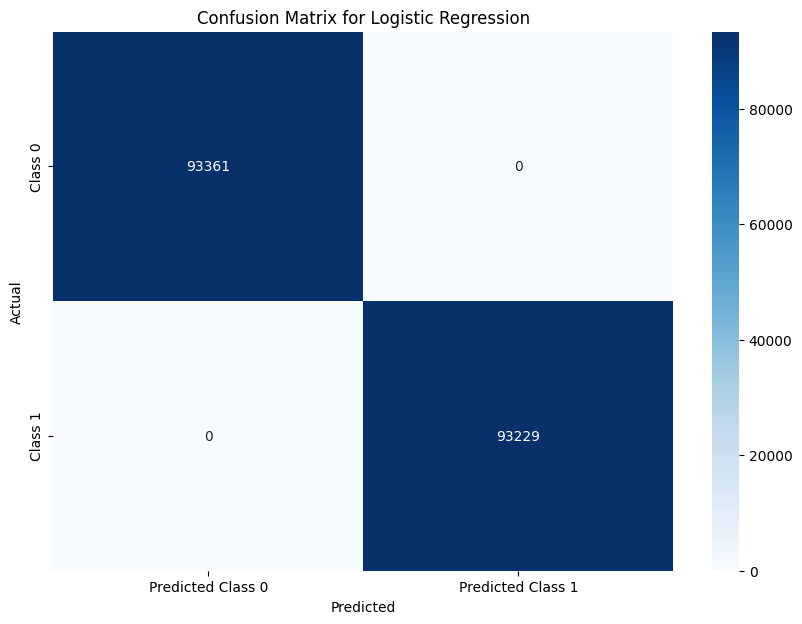

In [54]:

# Plot the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


# Random forest modeling

In [55]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder
from pyspark.ml.classification import RandomForestClassifier
from pyspark.sql.functions import col, when
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

# Define numerical, ordinal, and nominal columns
num_cols = ['Blood_Pressure', 'HDL_Cholesterol', 'LDL_Cholesterol', 'Triglycerides']
ordinal_cols = ['Smoking_History', 'Physical_Activity', 'Age_Quartile', 'Dietary_Habits']
nominal_cols = ['Gender', 'Obesity', 'Diabetes', 'Family_History', 'Heart_Attack_History']

In [56]:
 #Index and encode ordinal columns
ordinal_indexers = [StringIndexer(inputCol=col, outputCol=col + "_index").setHandleInvalid("skip") for col in ordinal_cols]

# Index and encode nominal columns
nominal_indexers = [StringIndexer(inputCol=col, outputCol=col + "_index").setHandleInvalid("skip") for col in nominal_cols]
nominal_encoders = [OneHotEncoder(inputCol=col + "_index", outputCol=col + "_encoded") for col in nominal_cols]

# Assemble all features into a single vector column
assembler = VectorAssembler(inputCols=num_cols + [col + "_index" for col in ordinal_cols] + [col + "_encoded" for col in nominal_cols], outputCol="features")

In [57]:
# Create a pipeline to handle the transformations
pipeline = Pipeline(stages=ordinal_indexers + nominal_indexers + nominal_encoders + [assembler])



In [58]:
# Fit and transform the data
pipeline_model = pipeline.fit(new_df_1)
assembled_df = pipeline_model.transform(new_df_1)


In [59]:
# Split the data into training and testing sets
train_df, test_df = assembled_df.randomSplit([0.8, 0.2], seed=42)

In [60]:
# Fit the Random Forest model on the training set
rf = RandomForestClassifier(featuresCol='features', labelCol='target', numTrees=80)
rf_model = rf.fit(train_df)



In [61]:
# Make predictions on the testing set
predictions = rf_model.transform(test_df)

# Show predictions
predictions.select('target', 'prediction', 'probability').show()

+------+----------+--------------------+
|target|prediction|         probability|
+------+----------+--------------------+
|     0|       1.0|[0.49608734011686...|
|     1|       0.0|[0.50301580973933...|
|     1|       1.0|[0.49920471872412...|
|     0|       1.0|[0.49960156151563...|
|     0|       1.0|[0.49880343587495...|
|     0|       1.0|[0.49568451588097...|
|     1|       1.0|[0.49937818122769...|
|     1|       1.0|[0.49794756580153...|
|     0|       1.0|[0.49604258115587...|
|     1|       0.0|[0.50073067744393...|
|     0|       1.0|[0.49718959121749...|
|     0|       0.0|[0.50549592757042...|
|     1|       1.0|[0.49707123551430...|
|     0|       1.0|[0.49795468946972...|
|     0|       0.0|[0.50423086797852...|
|     0|       1.0|[0.49866222424451...|
|     0|       0.0|[0.50208850167284...|
|     1|       0.0|[0.50236589426828...|
|     0|       1.0|[0.49468758101441...|
|     1|       1.0|[0.49955512428808...|
+------+----------+--------------------+
only showing top

In [63]:
# Evaluate the model using MulticlassClassificationEvaluator for accuracy
accuracy_evaluator = MulticlassClassificationEvaluator(labelCol='target', predictionCol='prediction', metricName='accuracy')
accuracy_rf = accuracy_evaluator.evaluate(predictions)
print(f"Model Accuracy: {accuracy_rf}")




Model Accuracy: 0.501312862843974


In [62]:
# Evaluate the model using BinaryClassificationEvaluator
evaluator = BinaryClassificationEvaluator(labelCol='target', rawPredictionCol='rawPrediction', metricName='areaUnderROC')
roc_auc = evaluator.evaluate(predictions)
print(f"Model ROC AUC: {roc_auc}")



Model ROC AUC: 0.5023700958295245


In [64]:
# Evaluate the model using MulticlassClassificationEvaluator for precision
precision_evaluator = MulticlassClassificationEvaluator(labelCol='target', predictionCol='prediction', metricName='weightedPrecision')
precision_rf = precision_evaluator.evaluate(predictions)
print(f"Model Precision: {precision_rf}")


Model Precision: 0.5013131271886178


In [65]:

# Evaluate the model using MulticlassClassificationEvaluator for recall
recall_evaluator = MulticlassClassificationEvaluator(labelCol='target', predictionCol='prediction', metricName='weightedRecall')
recall_rf = recall_evaluator.evaluate(predictions)
print(f"Model Recall: {recall_rf}")


Model Recall: 0.501312862843974


In [66]:
# Evaluate the model using MulticlassClassificationEvaluator for F1 score
f1_evaluator = MulticlassClassificationEvaluator(labelCol='target', predictionCol='prediction', metricName='f1')
f1_rf = f1_evaluator.evaluate(predictions)
print(f"Model F1 Score: {f1_rf}")


Model F1 Score: 0.5013128499181745


In [67]:
# Generate the confusion matrix
confusion_matrix = predictions.groupBy("target", "prediction").count()
confusion_matrix.show()

+------+----------+-----+
|target|prediction|count|
+------+----------+-----+
|     1|       0.0|31019|
|     0|       0.0|31213|
|     1|       1.0|31219|
|     0|       1.0|31086|
+------+----------+-----+



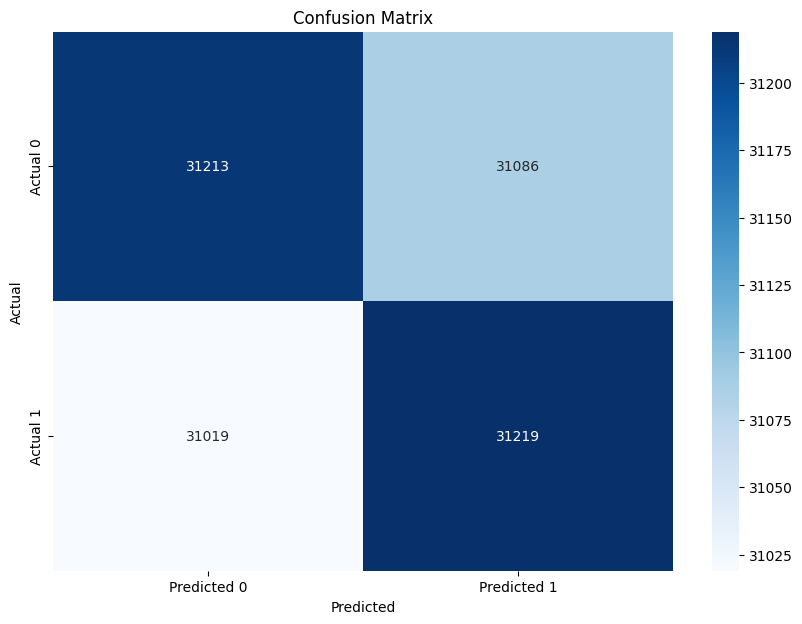

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder
from pyspark.ml.classification import RandomForestClassifier
from pyspark.sql.functions import col, when
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from sklearn.metrics import confusion_matrix
import numpy as np

# Convert predictions to Pandas DataFrame for plotting
predictions_pd = predictions.select('target', 'prediction').toPandas()

# Generate the confusion matrix
conf_matrix = confusion_matrix(predictions_pd['target'], predictions_pd['prediction'])

# Plot the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


# Decision tree

In [70]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.sql.functions import col, when
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# Define numerical, ordinal, and nominal columns
num_cols = ['Blood_Pressure', 'HDL_Cholesterol', 'LDL_Cholesterol', 'Triglycerides']
ordinal_cols = ['Smoking_History', 'Physical_Activity', 'Age_Quartile', 'Dietary_Habits']
nominal_cols = ['Gender', 'Obesity', 'Diabetes', 'Family_History', 'Heart_Attack_History']

# Index and encode ordinal columns
ordinal_indexers = [StringIndexer(inputCol=col, outputCol=col + "_index").setHandleInvalid("skip") for col in ordinal_cols]



In [71]:
# Index and encode nominal columns
nominal_indexers = [StringIndexer(inputCol=col, outputCol=col + "_index").setHandleInvalid("skip") for col in nominal_cols]
nominal_encoders = [OneHotEncoder(inputCol=col + "_index", outputCol=col + "_encoded") for col in nominal_cols]

# Assemble all features into a single vector column
assembler = VectorAssembler(inputCols=num_cols + [col + "_index" for col in ordinal_cols] + [col + "_encoded" for col in nominal_cols], outputCol="features")



In [72]:
# Create a pipeline to handle the transformations
pipeline = Pipeline(stages=ordinal_indexers + nominal_indexers + nominal_encoders + [assembler])

# Fit and transform the data
pipeline_model = pipeline.fit(new_df_1)
assembled_df = pipeline_model.transform(new_df_1)



In [73]:
# Split the data into training and testing sets
train_df, test_df = assembled_df.randomSplit([0.8, 0.2], seed=42)



In [74]:
# Fit the Decision Tree model on the training set
dt = DecisionTreeClassifier(featuresCol='features', labelCol='target')
dt_model = dt.fit(train_df)

# Make predictions on the testing set

In [75]:
predictions = dt_model.transform(test_df)

# Show predictions
predictions.select('target', 'prediction', 'probability').show()



+------+----------+--------------------+
|target|prediction|         probability|
+------+----------+--------------------+
|     0|       1.0|[0.47919418758256...|
|     1|       0.0|[0.50866856863109...|
|     1|       1.0|[0.49827956492621...|
|     0|       1.0|[0.49534997552618...|
|     0|       1.0|[0.49827956492621...|
|     0|       1.0|[0.49827956492621...|
|     1|       0.0|[0.50866856863109...|
|     1|       0.0|[0.50866856863109...|
|     0|       1.0|[0.49827956492621...|
|     1|       1.0|[0.49154334038054...|
|     0|       1.0|[0.49154334038054...|
|     0|       1.0|[0.49827956492621...|
|     1|       1.0|[0.47919418758256...|
|     0|       1.0|[0.49827956492621...|
|     0|       0.0|[0.50866856863109...|
|     0|       0.0|[0.51097780443911...|
|     0|       1.0|[0.49031146835079...|
|     1|       0.0|[0.51097780443911...|
|     0|       1.0|[0.49827956492621...|
|     1|       1.0|[0.49154334038054...|
+------+----------+--------------------+
only showing top

In [76]:
# Evaluate the model using BinaryClassificationEvaluator
evaluator = BinaryClassificationEvaluator(labelCol='target', rawPredictionCol='rawPrediction', metricName='areaUnderROC')
roc_auc = evaluator.evaluate(predictions)
print(f"Model ROC AUC: {roc_auc}")


Model ROC AUC: 0.49995137071384255


In [77]:

# Generate the confusion matrix
confusion_matrix = predictions.groupBy("target", "prediction").count()
confusion_matrix.show()

+------+----------+-----+
|target|prediction|count|
+------+----------+-----+
|     1|       0.0|36476|
|     0|       0.0|36684|
|     1|       1.0|25762|
|     0|       1.0|25615|
+------+----------+-----+



In [79]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.sql.functions import col, when
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator


In [80]:
# Evaluate the model using MulticlassClassificationEvaluator for accuracy
accuracy_evaluator = MulticlassClassificationEvaluator(labelCol='target', predictionCol='prediction', metricName='accuracy')
accuracy_dt = accuracy_evaluator.evaluate(predictions)
print(f"Model Accuracy: {accuracy_dt}")


Model Accuracy: 0.5014252792342838


In [81]:
# Evaluate the model using BinaryClassificationEvaluator
evaluator = BinaryClassificationEvaluator(labelCol='target', rawPredictionCol='rawPrediction', metricName='areaUnderROC')
roc_auc = evaluator.evaluate(predictions)
print(f"Model ROC AUC: {roc_auc}")

Model ROC AUC: 0.49995137071384255


In [82]:
# Evaluate the model using MulticlassClassificationEvaluator for precision
precision_evaluator = MulticlassClassificationEvaluator(labelCol='target', predictionCol='prediction', metricName='weightedPrecision')
precision_dt = precision_evaluator.evaluate(predictions)
print(f"Model Precision: {precision_dt}")


Model Precision: 0.5014260693152521


In [83]:

# Evaluate the model using MulticlassClassificationEvaluator for recall
recall_evaluator = MulticlassClassificationEvaluator(labelCol='target', predictionCol='prediction', metricName='weightedRecall')
recall_dt = recall_evaluator.evaluate(predictions)
print(f"Model Recall: {recall_dt}")


Model Recall: 0.5014252792342838


In [84]:

# Evaluate the model using MulticlassClassificationEvaluator for F1 score
f1_evaluator = MulticlassClassificationEvaluator(labelCol='target', predictionCol='prediction', metricName='f1')
f1_dt = f1_evaluator.evaluate(predictions)
print(f"Model F1 Score: {f1_dt}")

Model F1 Score: 0.4975823826038701


In [86]:

# Generate the confusion matrix
confusion_matrix = predictions.groupBy("target", "prediction").count()
confusion_matrix.show()

+------+----------+-----+
|target|prediction|count|
+------+----------+-----+
|     1|       0.0|36476|
|     0|       0.0|36684|
|     1|       1.0|25762|
|     0|       1.0|25615|
+------+----------+-----+



Model ROC AUC: 0.49995137071384255


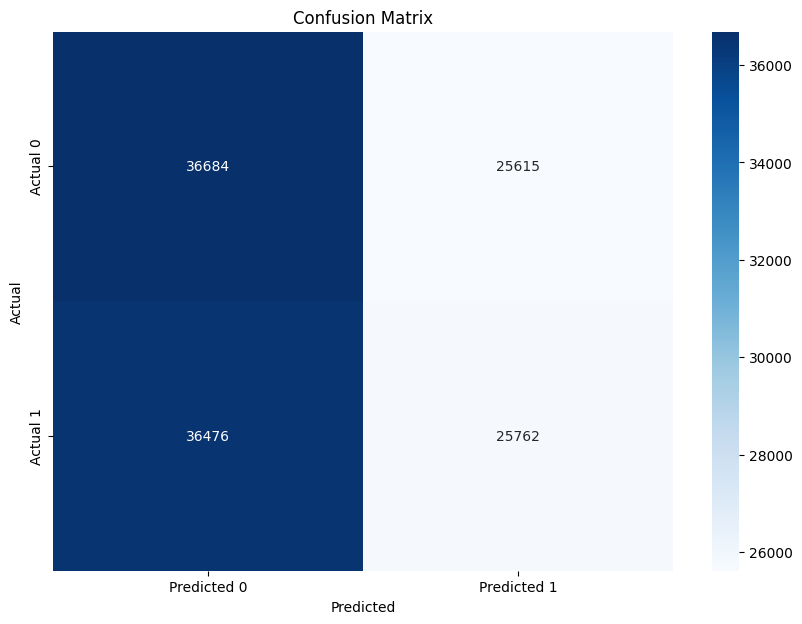

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.sql.functions import col, when
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from sklearn.metrics import confusion_matrix
import numpy as np

# Evaluate the model using BinaryClassificationEvaluator
evaluator = BinaryClassificationEvaluator(labelCol='target', rawPredictionCol='rawPrediction', metricName='areaUnderROC')
roc_auc = evaluator.evaluate(predictions)
print(f"Model ROC AUC: {roc_auc}")

# Convert predictions to Pandas DataFrame for plotting
predictions_pd = predictions.select('target', 'prediction').toPandas()

# Generate the confusion matrix
conf_matrix = confusion_matrix(predictions_pd['target'], predictions_pd['prediction'])

# Plot the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
